In [82]:
%pip install "git+https://github.com/ahicks778/persprot.git"

  Cloning https://github.com/ahicks778/persprot.git to /private/var/folders/cm/3rxw8bqj365d0j3nv2d9f4c80000gn/T/pip-req-build-cmptg2z4
  Running command git clone --filter=blob:none --quiet https://github.com/ahicks778/persprot.git /private/var/folders/cm/3rxw8bqj365d0j3nv2d9f4c80000gn/T/pip-req-build-cmptg2z4
  Resolved https://github.com/ahicks778/persprot.git to commit 65e21accffdabc439a19d84e7f8d0def352dfc33
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Correcting Fornax dSph Kinematics for Perspective Rotation

This notebook demonstrates how to apply the `persprot` package to real line-of-sight velocity data. We'll use a public dataset of Fornax member stars (Walker et al. 2009) to show how proper motion induces a false rotation signal across the dwarf galaxy, and how to effectively remove it.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import astropy.units as u
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import persprot as pr

# Standard publication plot styling
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9.5,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 1.0,
})

### 1. Fetching the Kinematic Data
First, we grab the kinematic catalog from VizieR (Walker+, 2009). We'll isolate highly probable Fornax members and extract their coordinates and heliocentric radial velocities.

In [70]:
print("Querying VizieR for Walker et al. 2009...")
v = Vizier(columns=['*'])
v.ROW_LIMIT = -1
data = v.get_catalogs('J/AJ/137/3100/stars')[0]

# Decode byte strings if necessary
target_strs = np.char.decode(data['Target'], 'utf-8') if isinstance(data['Target'][0], bytes) else np.asarray(data['Target'], dtype=str)

# Isolate Fornax targets with membership probability > 95%
is_fornax = np.char.startswith(np.char.lower(target_strs), 'for')
prob = data['Mmb'].filled(0.0) if hasattr(data['Mmb'], 'filled') else data['Mmb']
is_member = prob > 0.95

fornax_data = data[is_fornax & is_member]
print(f"Found {len(fornax_data)} highly probable Fornax members.")

# Parse coordinates and assign astropy units
coords = SkyCoord(fornax_data['RAJ2000'], fornax_data['DEJ2000'], unit=(u.hourangle, u.deg))
ra, dec = coords.ra, coords.dec

# Auto-detect velocity columns (VizieR column naming can be inconsistent)
v_col = '__HV_' if '__HV_' in fornax_data.colnames else 'HRV'
e_v_col = 'e__HV_' if 'e__HV_' in fornax_data.colnames else 'e_HRV'

v_los = np.asarray(fornax_data[v_col]) * (u.km / u.s)
e_v_los = np.asarray(fornax_data[e_v_col]) * (u.km / u.s)

Querying VizieR for Walker et al. 2009...
Found 2273 highly probable Fornax members.


### 2. Applying the Perspective Rotation Correction
With the catalog ready, we pass the coordinates and velocities into `pr.pcorr()`. By specifying `system_name="fornax_1"`, the package automatically retrieves the necessary systemic parameters (center, proper motions, and distance) from the Local Volume Database (LVDB) and computes the corrected velocities.

In [71]:
# Calculate the perspective correction
v_pc, e_v_pc = pr.pcorr(
    RA=ra, 
    DEC=dec, 
    v_los=v_los, 
    e_v_los=e_v_los,
    system_name='fornax_1'
)

# Grab Fornax's center coordinates directly from the LVDB for our plotting offsets
lvdb = pr.core._get_lvdb()
fornax_params = lvdb[np.char.find(np.asarray(lvdb['key_lower'], dtype=str), 'fornax') != -1][0]
ra0, dec0 = float(fornax_params['ra']), float(fornax_params['dec'])

# Convert to on-sky spatial offsets (degrees)
x = (ra.value - ra0) * np.cos(np.radians(dec0))
y = dec.value - dec0

# Extract raw arrays and drop invalid entries (NaNs, <=0 errors) for the fitting routine
v_raw_vals, ev_raw_vals = v_los.value, e_v_los.value
v_pc_vals, ev_pc_vals = v_pc.value, e_v_pc.value

valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(v_raw_vals) & (ev_raw_vals > 0) & np.isfinite(v_pc_vals)

x_c, y_c = x[valid], y[valid]
v_raw_c, ev_raw_c = v_raw_vals[valid], ev_raw_vals[valid]
v_pc_c, ev_pc_c = v_pc_vals[valid], ev_pc_vals[valid]


=== Perspective Correction Applied for fornax_1 ===
Corrected 2273 velocities.


### 3. Visualizing the Kinematic Impact
Finally, we fit a 2D kinematic plane to both the raw and corrected velocity fields to find their respective maximum gradient axes (and Position Angles). We'll plot the 1D profiles along these axes side-by-side with a 2D spatial map of the perspective correction term ($\Delta_p$) to visualize how the system's proper motion introduces the artificial gradient.

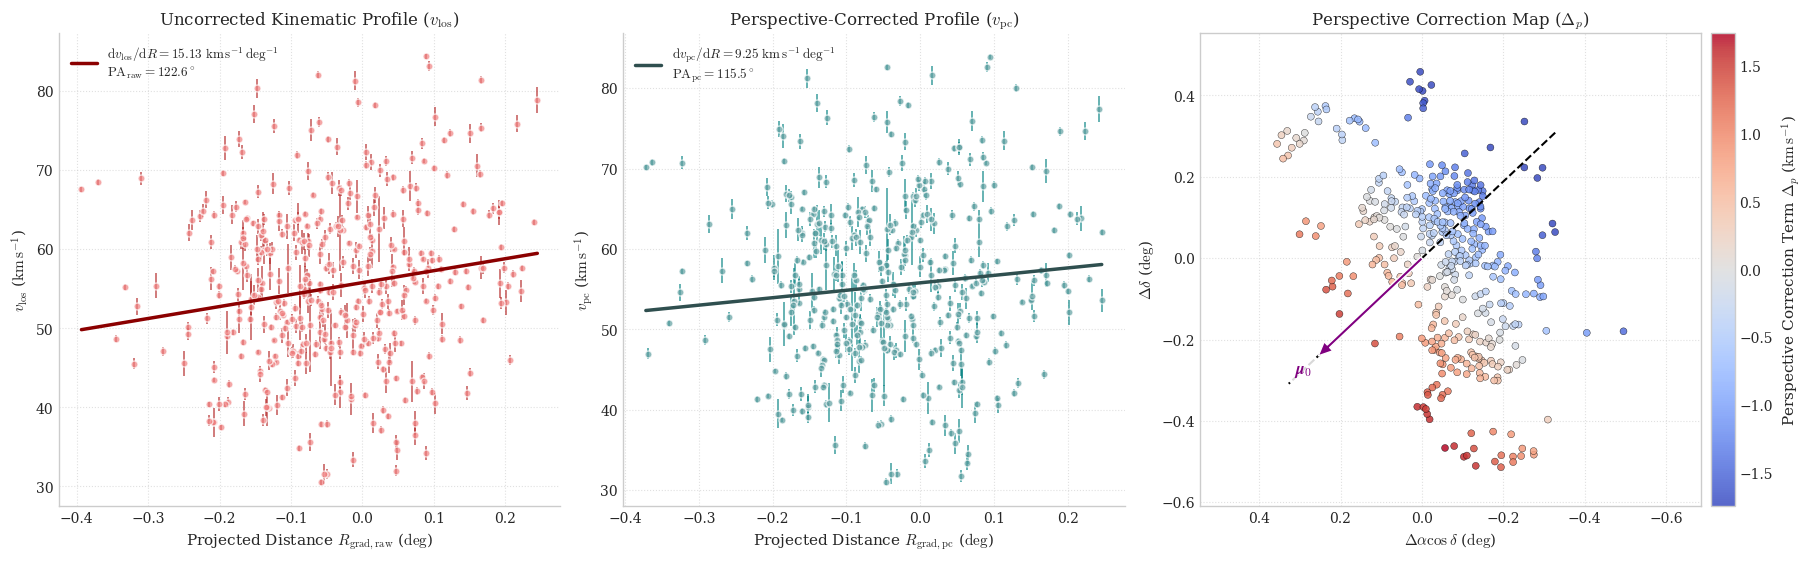

In [72]:
# --- Helper: 2D Kinematic Plane Fitting ---
def fit_2d_plane(x, y, v, ev):
    M = np.column_stack([x, y, np.ones_like(x)])
    w = 1.0 / ev  
    Mw = M * w[:, np.newaxis]
    vw = v * w
    try:
        params, _, _, _ = np.linalg.lstsq(Mw, vw, rcond=None)
    except np.linalg.LinAlgError:
        params, _, _, _ = np.linalg.lstsq(M, v, rcond=None)
    
    A, B, C = params
    grad_mag = np.sqrt(A**2 + B**2)
    pa = (90.0 - np.degrees(np.arctan2(B, A))) % 360.0
    R_grad = (A * x + B * y) / grad_mag if grad_mag > 0 else np.zeros_like(x)
    
    return A, B, C, grad_mag, pa, R_grad

# Fit 2D planes for raw and corrected LOS velocities
A_raw, B_raw, C_raw, grad_raw, pa_raw, R_grad_raw = fit_2d_plane(x_c, y_c, v_raw_c, ev_raw_c)
A_pc, B_pc, C_pc, grad_pc, pa_pc, R_grad_pc = fit_2d_plane(x_c, y_c, v_pc_c, ev_pc_c)

# Perspective Correction Term (\Delta_p) following Hicks & Geha notation
delta_p = v_raw_c - v_pc_c

# Proper motion inputs for the spatial map vector (\mu_\alpha*, \mu_\delta)
mu_ra = float(fornax_params['pmra'])   
mu_dec = float(fornax_params['pmdec']) 
pm_mag = np.sqrt(mu_ra**2 + mu_dec**2)

pm_dir_x = mu_ra / pm_mag if pm_mag > 0 else 0
pm_dir_y = mu_dec / pm_mag if pm_mag > 0 else 0


# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), layout='constrained')

# 1. Uncorrected Profile (v_los)
axes[0].errorbar(R_grad_raw, v_raw_c, yerr=ev_raw_c, fmt='o', 
                 color='firebrick', markerfacecolor='lightcoral', markeredgecolor='white',
                 alpha=0.7, markersize=5, elinewidth=1.2, zorder=1)

r_fit_raw = np.linspace(np.min(R_grad_raw), np.max(R_grad_raw), 100)
raw_label = (r'$\mathrm{d}v_{\mathrm{los}}/\mathrm{d}R = ' + f'{grad_raw:.2f}' + r'\ \mathrm{km\,s^{-1}\,deg^{-1}}$' + '\n' +
             r'$\mathrm{PA}_{\mathrm{raw}} = ' + f'{pa_raw:.1f}' + r'^\circ$')

axes[0].plot(r_fit_raw, grad_raw * r_fit_raw + C_raw, color='darkred', lw=2.5, label=raw_label, zorder=2)
axes[0].set(title=r"Uncorrected Kinematic Profile ($v_{\mathrm{los}}$)", 
            xlabel=r"Projected Distance $R_{\mathrm{grad, raw}}$ ($\mathrm{deg}$)", 
            ylabel=r"$v_{\mathrm{los}}$ ($\mathrm{km\,s^{-1}}$)")
axes[0].legend(loc='upper left', frameon=False)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Perspective-Corrected Profile (v_pc)
axes[1].errorbar(R_grad_pc, v_pc_c, yerr=ev_pc_c, fmt='o', 
                 color='teal', markerfacecolor='cadetblue', markeredgecolor='white',
                 alpha=0.7, markersize=5, elinewidth=1.2, zorder=1)

r_fit_pc = np.linspace(np.min(R_grad_pc), np.max(R_grad_pc), 100)
pc_label = (r'$\mathrm{d}v_{\mathrm{pc}}/\mathrm{d}R = ' + f'{grad_pc:.2f}' + r'\ \mathrm{km\,s^{-1}\,deg^{-1}}$' + '\n' +
            r'$\mathrm{PA}_{\mathrm{pc}} = ' + f'{pa_pc:.1f}' + r'^\circ$')

axes[1].plot(r_fit_pc, grad_pc * r_fit_pc + C_pc, color='darkslategray', lw=2.5, label=pc_label, zorder=2)
axes[1].set(title=r"Perspective-Corrected Profile ($v_{\mathrm{pc}}$)", 
            xlabel=r"Projected Distance $R_{\mathrm{grad, pc}}$ ($\mathrm{deg}$)", 
            ylabel=r"$v_{\mathrm{pc}}$ ($\mathrm{km\,s^{-1}}$)")
axes[1].legend(loc='upper left', frameon=False)
axes[1].grid(True, linestyle=':', alpha=0.6)

# 3. 2D Perspective Correction Map (\Delta_p)
diff_lim = np.percentile(np.abs(delta_p), 98)
norm_diff = mcolors.TwoSlopeNorm(vmin=-diff_lim, vcenter=0.0, vmax=diff_lim)

sc3 = axes[2].scatter(x_c, y_c, c=delta_p, cmap='coolwarm', norm=norm_diff, 
                      s=25, alpha=0.85, edgecolor='black', linewidth=0.3)

cbar3 = plt.colorbar(sc3, ax=axes[2], pad=0.02)
cbar3.set_label(r"Perspective Correction Term $\Delta_p$ ($\mathrm{km\,s^{-1}}$)")

# Proper Motion Axis & Vector
pm_axis_len = 0.45
axes[2].plot([-pm_dir_x * pm_axis_len, pm_dir_x * pm_axis_len],
             [-pm_dir_y * pm_axis_len, pm_dir_y * pm_axis_len],
             color='black', linestyle='--', linewidth=1.5, zorder=8, label=r'PM Axis ($\boldsymbol{\mu}_0$)')

arrow_scale = 0.35
axes[2].annotate('', xy=(pm_dir_x * arrow_scale, pm_dir_y * arrow_scale), xytext=(0, 0),
                arrowprops=dict(facecolor='purple', edgecolor='white', width=2.5, headwidth=9, headlength=10), zorder=10)

axes[2].text(pm_dir_x * arrow_scale * 1.15, pm_dir_y * arrow_scale * 1.15, r"$\boldsymbol{\mu}_0$", 
            color='purple', fontweight='bold', fontsize=12, ha='center', va='center', zorder=11,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='none'))

axes[2].set(title=r"Perspective Correction Map ($\Delta_p$)", 
            xlabel=r"$\Delta\alpha \cos\delta$ ($\mathrm{deg}$)", 
            ylabel=r"$\Delta\delta$ ($\mathrm{deg}$)")
axes[2].invert_xaxis()
axes[2].set_aspect('equal', adjustable='datalim')
axes[2].grid(True, linestyle=':', alpha=0.6)

# Clean up layout
for ax in axes[:2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

### 4. Comparing the Perspective Gradient to the Observed Gradient

Finally we will compute the gradient difference between the raw and perspective-corrected gradients, and compare it to the perspective gradient computed by the `persprot` package. This will allow us to quantify the effect of perspective rotation on the observed kinematics of Fornax.

In [80]:
## Compute the gradient parallel and perpendicular to the proper motion axis
pm_unit_vec = np.array([pm_dir_x, pm_dir_y])
pm_perp_vec = np.array([-pm_dir_y, pm_dir_x])

grad_vec_raw = np.array([A_raw, B_raw])
grad_vec_pc = np.array([A_pc, B_pc])

# Along Proper Motion Axis
grad_along_pm_raw = np.dot(grad_vec_raw, pm_unit_vec)
grad_along_pm_pc = np.dot(grad_vec_pc, pm_unit_vec)

# Orthogonal to Proper Motion Axis
grad_perp_pm_raw = np.dot(grad_vec_raw, pm_perp_vec)
grad_perp_pm_pc = np.dot(grad_vec_pc, pm_perp_vec)

diff_along_pm = grad_along_pm_raw - grad_along_pm_pc
diff_perp_pm = grad_perp_pm_raw - grad_perp_pm_pc

print("-" * 50)
print("VELOCITY GRADIENT ANALYSIS (km/s/deg)")
print("-" * 50)

print(f"ALONG Proper Motion Axis:")
print(f"  Raw Gradient:       {grad_along_pm_raw:>8.3f}")
print(f"  Corrected Gradient: {grad_along_pm_pc:>8.3f}")
print(f"  Difference (Raw-PC):{diff_along_pm:>8.3f}")
print()

print(f"ORTHOGONAL to Proper Motion Axis:")
print(f"  Raw Gradient:       {grad_perp_pm_raw:>8.3f}")
print(f"  Corrected Gradient: {grad_perp_pm_pc:>8.3f}")
print(f"  Difference (Raw-PC):{diff_perp_pm:>8.3f}")
print("-" * 50)

## Compute the perspective gradient in degrees using the persprot package
pgrad = pr.pgrad('fornax_1', verbose=True, scale_unit=1*u.deg)

--------------------------------------------------
VELOCITY GRADIENT ANALYSIS (km/s/deg)
--------------------------------------------------
ALONG Proper Motion Axis:
  Raw Gradient:         14.873
  Corrected Gradient:    8.811
  Difference (Raw-PC):   6.062

ORTHOGONAL to Proper Motion Axis:
  Raw Gradient:          2.797
  Corrected Gradient:    2.823
  Difference (Raw-PC):  -0.026
--------------------------------------------------

=== Gradient Results for fornax_1 ===
Gradient: 6.175 km/s. Position Angle: 133.3 deg
